# Chunk 1 — Pandas warmup on SPY data

**Goal:** get fluent enough in pandas to manipulate time series without fighting the library.

**Focus concepts** (from the plan):
- `DatetimeIndex`
- `.loc` vs `.iloc`
- Rolling windows (`.rolling(N).mean()`)
- `.shift(1)` — crucial for avoiding lookahead bias later
- `.pct_change()` / `.diff()`

**Ground rules:** fill in the `TODO` cells yourself. When stuck, stop and ask — don't copy from elsewhere. The point is to build the mental model, not produce a working notebook fast.

We're using SPY (S&P 500 ETF) for the rest of the project. In Chunk 1, we're just using one year of it as a pandas sandbox. Chunk 2 is where we pull the full 10 years and focus on returns.

## 1. Imports

Run this. If anything fails, flag the error.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print(f"pandas: {pd.__version__}")
print(f"numpy:  {np.__version__}")
print(f"yfinance: {yf.__version__}")

Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.2
numpy:  2.2.6
yfinance: 1.3.0


## 2. Download SPY — just 2023

`yfinance` wraps Yahoo Finance's API. `auto_adjust=True` gives us prices adjusted for splits and dividends (we'll talk about why this matters in Chunk 2).

In [2]:
df = yf.download("SPY", start="2023-01-01", end="2023-12-31", auto_adjust=True)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2023-01-03,365.072083,370.450080,362.205707,368.475269,74850700
2023-01-04,367.890472,369.922800,364.285949,367.334441,85934100
2023-01-05,363.691650,366.049915,363.097294,365.934882,76970500
2023-01-06,372.031830,373.153460,363.720374,366.788028,104189600
2023-01-09,371.820862,377.419387,371.638746,374.227075,73978100


### ⚠️ Possible gotcha: MultiIndex columns

Depending on the yfinance version, `df.columns` might be a `MultiIndex` — i.e. each column is a tuple like `('Close', 'SPY')` instead of just `'Close'`. If `df.head()` above shows a double-row header with `'SPY'` as the second level, run the next cell to flatten it. Otherwise skip it.

Check with: `print(type(df.columns))` and `print(df.columns)`.

In [4]:
# Inspect the columns. If it prints a MultiIndex, uncomment the flatten line.
print(type(df.columns))
print(df.columns)

df.columns = df.columns.get_level_values(0)   # <- uncomment only if needed
df.head()

<class 'pandas.MultiIndex'>
MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,365.072083,370.450080,362.205707,368.475269,74850700
2023-01-04,367.890472,369.922800,364.285949,367.334441,85934100
2023-01-05,363.691650,366.049915,363.097294,365.934882,76970500
2023-01-06,372.031830,373.153460,363.720374,366.788028,104189600
2023-01-09,371.820862,377.419387,371.638746,374.227075,73978100


## 3. Inspect the DataFrame

Three things to check:
1. What type is the **index**? (This is the key one — is it a `DatetimeIndex`?)
2. What are the **column dtypes**?
3. What's the **shape**? Does the row count roughly match "trading days in 2023" (hint: ~252)?

Fill in the TODO.

In [5]:
# TODO: print the following three things, one per line:
#   - df.index  (look at the type + first/last few values)
#   - df.dtypes
#   - df.shape
print(df.index)
print(df.dtypes)
print(df.shape)

DatetimeIndex(['2023-01-03', '2023-01-04', '2023-01-05', '2023-01-06',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-17',
               ...
               '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
               '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
               '2023-12-28', '2023-12-29'],
              dtype='datetime64[s]', name='Date', length=250, freq=None)
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object
(250, 5)


**Pause and reflect:**
- Was the index a `DatetimeIndex`? Why does that matter? (Hint: think about what `df.loc["2023-06"]` would or wouldn't do.)
- How many rows did you get? Why isn't it 365?

## 4. Rolling windows

A **20-day Simple Moving Average (SMA)** is: for each date `t`, the average closing price over days `t-19` through `t` (inclusive). Pandas has this built in:

```python
df["Close"].rolling(window=N).mean()
```

Fill in the TODO.

In [6]:
# TODO: compute a 20-day rolling mean of the Close price and store it in a new column 'SMA_20'
# df["SMA_20"] = ...
df["SMA_20"] = df["Close"].rolling(window=20).mean()
# then show the first 25 rows of just Close and SMA_20
df[["Close", "SMA_20"]].head(25)


Price,Close,SMA_20
Date,,
2023-01-03,365.072083,NaN
2023-01-04,367.890472,NaN
2023-01-05,363.691650,NaN
2023-01-06,372.031830,NaN
2023-01-09,371.820862,NaN
2023-01-10,374.428406,NaN
2023-01-11,379.164185,NaN
2023-01-12,380.544586,NaN
2023-01-13,382.020905,NaN


**Question:** The first several rows of `SMA_20` are `NaN`. How many, and why?

(Answer it in your head before moving on.)

## 5. `.shift(1)` — the single most important function in this project

`df["Close"].shift(1)` moves all values down by one row. So on row `t`, you now see the value that was on row `t-1` of the original column.

Put another way: `.shift(1)` of the `Close` column at row `t` gives you **yesterday's** close, aligned to today's row.

**Why this matters for ML:** if you want to use yesterday's price as a feature to predict today, you shift. If you flip the direction (`.shift(-1)`), you've leaked the future into the present — your model will look magical and be wrong.

Run this to see:

In [7]:
df["Close_prev"] = df["Close"].shift(1)
df[["Close", "Close_prev"]].head()

Price,Close,Close_prev
Date,,
2023-01-03,365.072083,NaN
2023-01-04,367.890472,365.072083
2023-01-05,363.691650,367.890472
2023-01-06,372.031830,363.691650
2023-01-09,371.820862,372.031830


**Question:** What's in `Close_prev` on the very first row? Why is that correct behavior?

## 6. `pct_change` — daily simple returns

Daily simple return: $r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$.

Pandas shortcut: `df["Close"].pct_change()`.

**Prove to yourself it's the same as the manual formula.** If both columns are identical (after dropping NaNs), you've confirmed you understand what `pct_change` does.

In [10]:
df["return_builtin"] = df["Close"].pct_change()

# TODO: compute the same thing manually using shift, store in 'return_manual'
df["return_manual"] = (df["Close"] - df["Close"].shift(1)) / df["Close"].shift(1)

# then compare — the last line should print True
np.allclose(df["return_builtin"].dropna(), df["return_manual"].dropna())


True

## 7. Plot

Quick sanity check — the Close price with its 20-day SMA overlaid.

You'll notice the SMA is a smoothed version of price that lags behind it. That's the whole point.

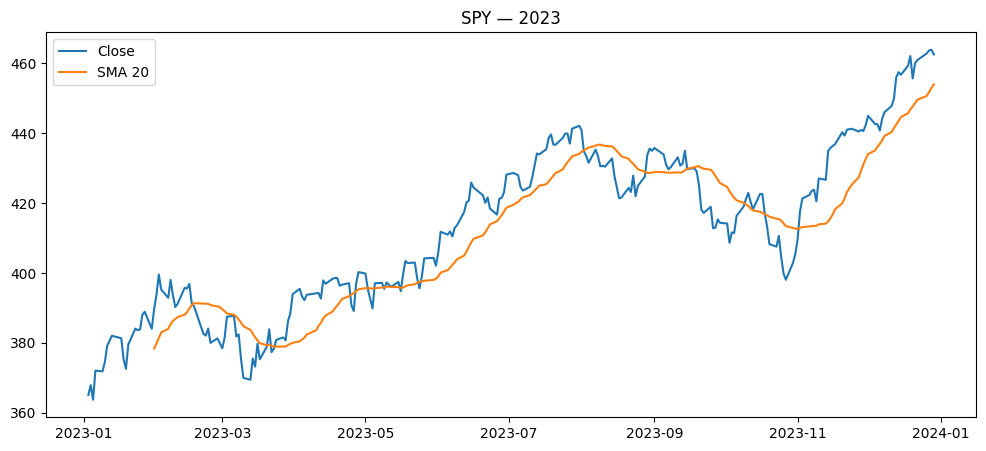

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["Close"], label="Close")
ax.plot(df.index, df["SMA_20"], label="SMA 20")
ax.set_title("SPY — 2023")
ax.legend()
plt.show()

## Done-when checklist

Before we move to Chunk 2, you should be able to answer (out loud, in your head, doesn't matter):

- [ ] What's a `DatetimeIndex` and why does time series data use it?
- [ ] What does `.rolling(N).mean()` do, and why are the first `N-1` values `NaN`?
- [ ] What does `.shift(1)` do? What would `.shift(-1)` do, and why is that dangerous in a training pipeline?
- [ ] How would you compute `pct_change` manually using `.shift(1)`?

When those feel obvious, ping me and we'll move to Chunk 2 (full 10-year dataset, log returns, stationarity).